In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem, t, pearsonr
import seaborn as sns
from collections import Counter

from nltk.corpus import stopwords
import string

import nltk
from sklearn.feature_extraction.text import CountVectorizer as CV

from scipy.special import softmax
from scipy.stats import entropy

In [2]:
data_dir = os.path.join(os.getcwd(), 'legal-data')
df = pd.read_csv(os.path.join(data_dir, 'reasoning.csv'))

In [3]:
def create_proj_id(row):
    proj_id = f"{row['project_case_id']}_{row['project_opinion_id']}"
    return proj_id

df["proj_id"] = df.apply(create_proj_id, axis = 1)
len(df["proj_id"].drop_duplicates())

36430

In [4]:
annotations_df = pd.read_csv(os.path.join(data_dir, 'legal_reasoning_annotations.csv'))

In [5]:
training_df = pd.read_csv(os.path.join(data_dir, 'eval_crossfold_output.csv'))
training_df.head()


,Unnamed: 0,model,percentage,split,macro_f1,macro_precision,macro_recall,weighted_f1,weighted_precision,weighted_recall,grand_f1,grand_precision,grand_recall,formal_f1,formal_precision,formal_recall,none_f1,none_precision,none_recall
0,0,nlpaueb/legal-bert-base-uncased,0.1,0,0.240,0.188,0.333,0.406,0.318,0.564,0.0,0.0,0.0,0.0,0.0,0.0,0.721,0.564,1.0
1,0,nlpaueb/legal-bert-base-uncased,0.1,1,0.296,0.267,0.333,0.711,0.640,0.800,0.0,0.0,0.0,0.0,0.0,0.0,0.889,0.800,1.0
2,0,nlpaueb/legal-bert-base-uncased,0.1,2,0.296,0.267,0.333,0.711,0.640,0.800,0.0,0.0,0.0,0.0,0.0,0.0,0.889,0.800,1.0
3,0,nlpaueb/legal-bert-base-uncased,0.1,3,0.296,0.267,0.333,0.711,0.640,0.800,0.0,0.0,0.0,0.0,0.0,0.0,0.889,0.800,1.0
4,0,nlpaueb/legal-bert-base-uncased,0.1,4,0.296,0.267,0.333,0.711,0.640,0.800,0.0,0.0,0.0,0.0,0.0,0.0,0.889,0.800,1.0


In [6]:
print(max(df['year']))
print(min(df['year']))

2024
1870


In [7]:
len(list(df['project_case_id'].drop_duplicates()))

24890

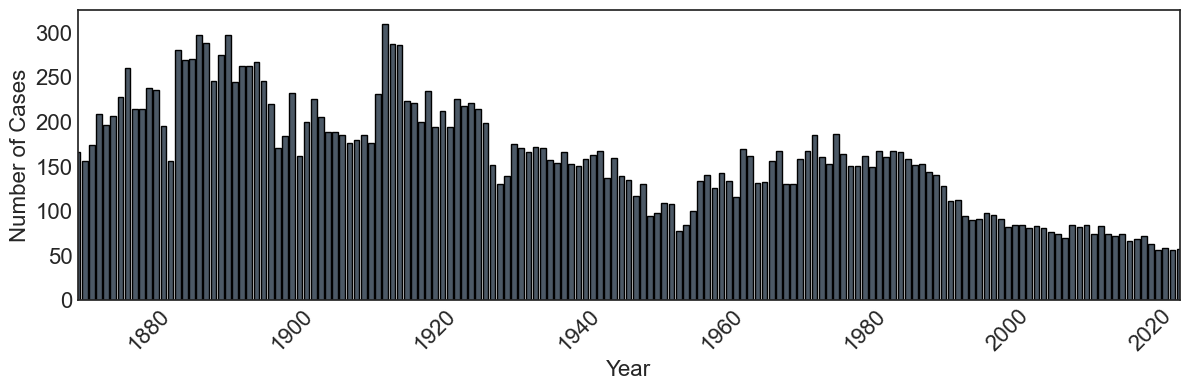

In [ ]:
unique_case_ids_per_year = df.groupby('year')['project_case_id'].nunique()


plt.style.use('seaborn-v0_8-white')

plt.figure(figsize=(12, 4))
plt.bar(unique_case_ids_per_year.index, unique_case_ids_per_year.values,  color='#4C5966', edgecolor='black')
plt.xlabel('Year', fontsize=16)
plt.ylabel('Number of Cases', fontsize=16)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)

plt.xlim(1870, 2024)
plt.tight_layout()
plt.savefig('tiff-figures/cases_over_time.tiff', format='tiff', dpi=300)
plt.savefig('figures/cases_over_time.png', format='png', dpi=300)

plt.show()

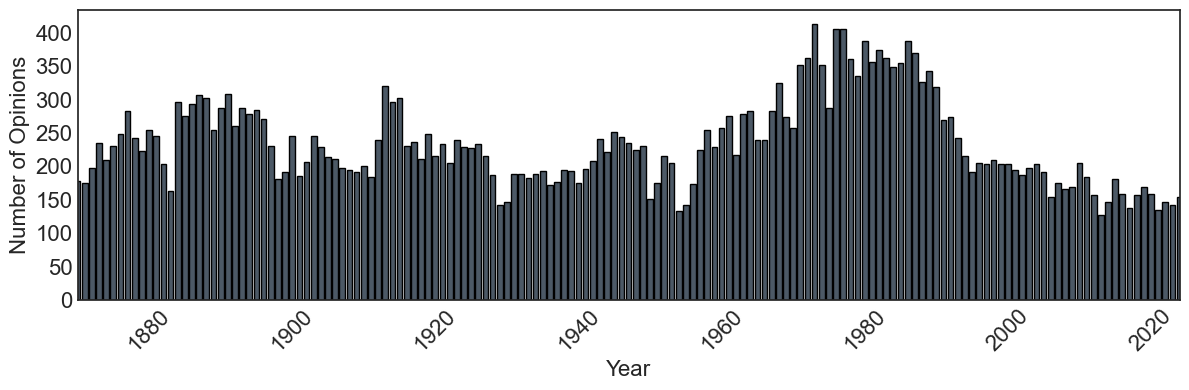

In [ ]:
unique_proj_ids_per_year = df.groupby('year')['proj_id'].nunique()

plt.style.use('seaborn-v0_8-white')

plt.figure(figsize=(12, 4))
plt.bar(unique_proj_ids_per_year.index, unique_proj_ids_per_year.values,  color='#4C5966', edgecolor='black')
plt.xlabel('Year', fontsize=16)
plt.ylabel('Number of Opinions', fontsize=16)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)

# plt.grid(True
plt.xlim(1870, 2024)
plt.tight_layout()
plt.savefig('tiff-figures/opinions_over_time.tiff', format='tiff', dpi=300)
plt.savefig('figures/opinions_over_time.png', format='png', dpi=300)

plt.show()

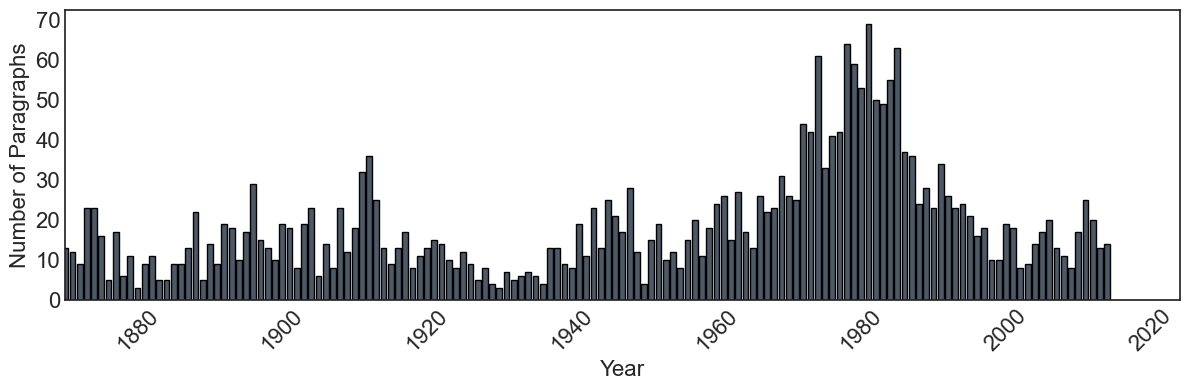

In [ ]:
unique_paras_per_year = annotations_df.groupby('year')['section_id'].nunique()

plt.style.use('seaborn-v0_8-white')

plt.figure(figsize=(12, 4))
plt.bar(unique_paras_per_year.index, unique_paras_per_year.values,  color='#4C5966', edgecolor='black')
plt.xlabel('Year', fontsize=16)
plt.ylabel('Number of Paragraphs', fontsize=16)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)

plt.xlim(1870, 2024)
plt.tight_layout()
plt.savefig('tiff-figures/annotations_over_time.tiff', format='tiff', dpi=300)
plt.savefig('figures/annotations_over_time.png', format='png', dpi=300)

plt.show()

/var/folders/jp/gzgqr0zj4375330zk80zz1sc0000gn/T/ipykernel_14612/2681361951.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ave_df["model"] = ave_df["model"].map(model_dict)


<Figure size 1000x600 with 0 Axes>

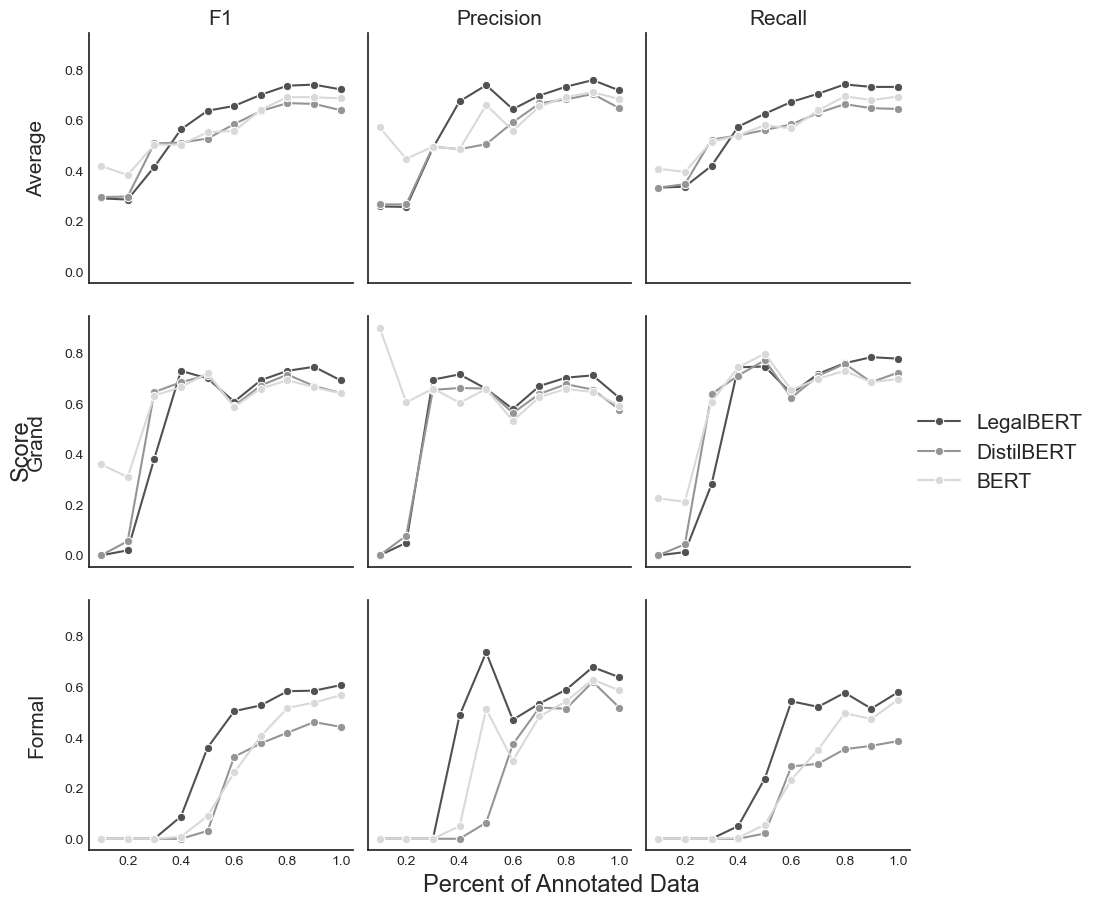

In [ ]:

ave_df = training_df[training_df["split"] == "averages"]


model_dict = {
    "nlpaueb/legal-bert-base-uncased": "LegalBERT",
    "distilbert/distilbert-base-uncased": "DistilBERT",
    "google-bert/bert-base-uncased": "BERT"
}
ave_df["model"] = ave_df["model"].map(model_dict)

cols = ['macro_f1', 'macro_precision', 'macro_recall', 'grand_f1', 'grand_precision', 'grand_recall',
       'formal_f1', 'formal_precision', 'formal_recall']

melted_df = ave_df.melt(id_vars=['percentage', 'model'], 
                        value_vars=cols, 
                        var_name='metric', 
                        value_name='value')

plt.figure(figsize=(10, 6))

font_size = 15

grayscale_palette = sns.color_palette("Greys", len(model_dict))[::-1]

g = sns.FacetGrid(melted_df, col="metric", hue="model", height=3, aspect=1, sharey=True, col_wrap=3, palette=grayscale_palette)

g.map(sns.lineplot, 'percentage', 'value', marker="o")
g.add_legend(title="", fontsize=font_size)
g.set_titles("") 

for ax, metric in zip(g.axes.flat, ['F1', 'Precision', 'Recall']):
    ax.set_title(metric, fontsize=font_size)


row_headers = ["Average", "Grand", "Formal"]  
row_count = len(row_headers)

for i, ax in enumerate(g.axes):
    if i % row_count == 0:  
        header = row_headers[i // row_count]
        ax.annotate(header, xy=(-0.2, 0.5), xycoords='axes fraction', 
                    fontsize=font_size, rotation=90, ha='center', va='center')
    ax.set_ylabel("")  
    ax.set_xlabel("")  

plt.gcf().text(0.5, 0.01, 'Percent of Annotated Data', ha='center', fontsize=17) 
plt.gcf().text(-0.01, 0.5, 'Score', va='center', rotation=90, fontsize=17)
plt.savefig(os.path.join(os.getcwd(), 'tiff-figures', 'eval_scores.tiff'), dpi=300, format='tiff', bbox_inches='tight')
plt.savefig(os.path.join(os.getcwd(), 'figures', 'eval_scores.png'), dpi=300, format='png', bbox_inches='tight')

plt.show()

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rosamondthalken/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Vocab size is 300


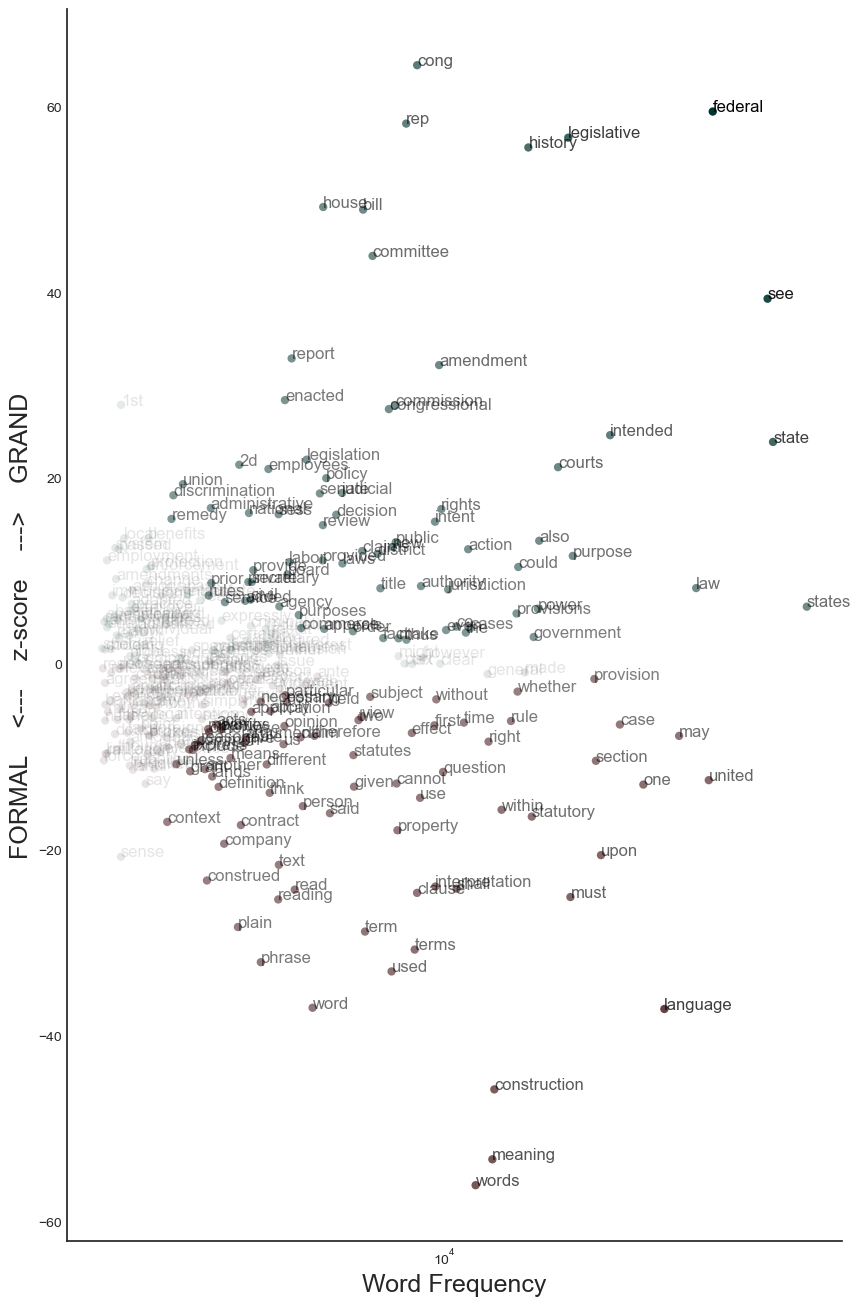

In [ ]:
new_predictions = pd.read_csv(os.path.join(data_dir, 'new_predictions.csv'))
old_predictions = pd.read_csv(os.path.join(data_dir, 'predictions.csv'))

predictions = pd.concat([new_predictions, old_predictions])

class_dict = {
    2:"None",
    1:"Grand",
    0: "Formal"
}
predictions['class'] = predictions['predicted_class'].map(class_dict)

grand_paras = predictions[predictions['class'] == 'Grand']['paragraph'].tolist()
formal_paras = predictions[predictions['class'] == 'Formal']['paragraph'].tolist()

nltk.download('stopwords')
exclude = set(string.punctuation)

remove_words = stopwords.words('english')
def basic_sanitize(in_string, remove_words):
    '''Returns a very roughly sanitized version of the input string.'''  
    in_string = ''.join([ch for ch in in_string if ch not in exclude])
    in_string = in_string.lower()
    in_string = [word for word in in_string.split() if word not in remove_words]
    in_string = ' '.join(in_string)
    return in_string

cv = CV(decode_error = 'ignore', 
                max_df = .30, 
                min_df = 300, 
                binary = False, 
                max_features = 300)   # min_df = 20
vector = cv.fit_transform(grand_paras, formal_paras)
priors = np.sum(vector, axis=0).astype(int)
priors = np.squeeze(np.asarray(priors))

l1 = grand_paras
l2 = formal_paras
l1 = [basic_sanitize(l, remove_words) for l in l1]
l2 = [basic_sanitize(l, remove_words) for l in l2]

counts_mat = cv.fit_transform(l1+l2).toarray()
vocab_size = len(cv.vocabulary_)
print("Vocab size is {}".format(vocab_size))

z_scores = np.empty(priors.shape[0])
count_matrix = np.empty([2, vocab_size], dtype=np.float32)
count_matrix[0, :] = np.sum(counts_mat[:len(l1), :], axis = 0)
count_matrix[1, :] = np.sum(counts_mat[len(l1):, :], axis = 0)
a0 = np.sum(priors)
n1 = 1.*np.sum(count_matrix[0,:])
n2 = 1.*np.sum(count_matrix[1,:])

for i in range(vocab_size):
    term1 = np.log((count_matrix[0,i] + priors[i])/(n1 + a0 - count_matrix[0,i] - priors[i]))
    term2 = np.log((count_matrix[1,i] + priors[i])/(n2 + a0 - count_matrix[1,i] - priors[i]))        
    delta = term1 - term2

    var = 1./(count_matrix[0,i] + priors[i]) + 1./(count_matrix[1,i] + priors[i])
    z_scores[i] = delta/np.sqrt(var)

index_to_term = {v: k for k, v in cv.vocabulary_.items()}
sorted_indices = np.argsort(z_scores)
return_list = [(index_to_term[i], z_scores[i]) for i in sorted_indices]

sig_val = 0
x_vals = count_matrix.sum(axis=0)
y_vals = z_scores
sizes = abs(z_scores) * 2
neg_color, pos_color, insig_color = ('#340509', '#053430', '#d8d8d8')
colors = []
annots = []

# Normalize x_vals and y_vals for alpha calculation
x_norm = (x_vals - x_vals.min()) / (x_vals.max() - x_vals.min())
y_norm = (abs(y_vals) - abs(y_vals).min()) / (abs(y_vals).max() - abs(y_vals).min())

# Compute combined score
combined_score = x_norm * y_norm

# Find median combined score
median_score = np.median(combined_score)# +.01

# Compute original and boosted alpha
original_alpha = 0.1 + 0.89 * (combined_score / combined_score.max())  # Original scaling
boosted_alpha = 0.5 + 0.5 * ((combined_score - median_score) / (combined_score.max() - median_score))  # Boost top half

# Apply alpha logic to both points and annotations
adjusted_alpha = np.where(combined_score >= median_score, boosted_alpha, original_alpha)

for i, y in enumerate(y_vals):
    if y > sig_val:
        colors.append(pos_color)
        annots.append(index_to_term[i])
    elif y < -sig_val:
        colors.append(neg_color)
        annots.append(index_to_term[i])
    else:
        colors.append(insig_color)
        annots.append(None)

fig, ax = plt.subplots(figsize=(10, 16))

# Apply adjusted alpha to scatter points
ax.scatter(x_vals, y_vals, c=colors, linewidth=0, alpha=adjusted_alpha)

# Annotate significant points with adjusted alpha
for i, annot in enumerate(annots):
    if annot is not None:
        alpha = min(adjusted_alpha[i], 0.99)  # Ensure max is 0.99
        if np.abs(y_vals[i]) > sig_val:
            ax.annotate(annot, (x_vals[i], y_vals[i]), color='black', alpha=alpha, fontsize=12)

ax.set_xscale('log')
plt.xlabel("Word Frequency", fontsize=18)
plt.ylabel("FORMAL    <---    z-score    --->    GRAND", fontsize=18)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.savefig(os.path.join(os.getcwd(), 'tiff-figures', 'fightin_words.tiff'),format='tiff', dpi=200)
plt.savefig(os.path.join(os.getcwd(), 'figures', 'fightin_words.png'),format='png', dpi=200)

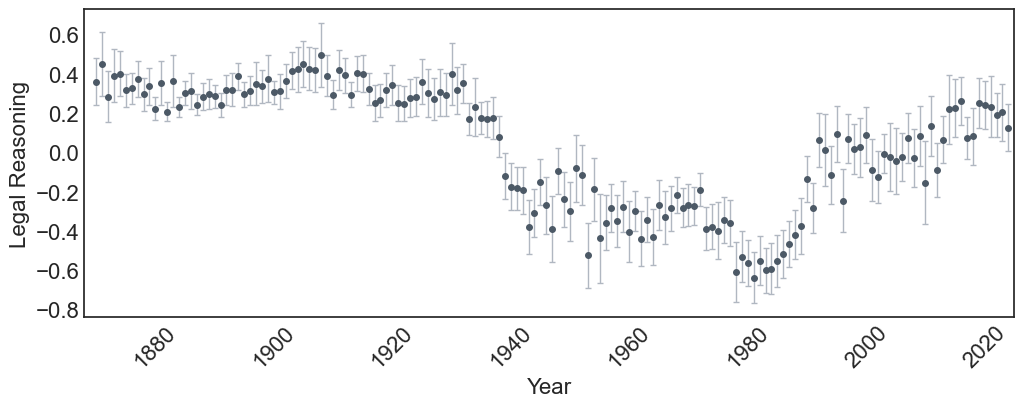

In [ ]:
z = 1.96
grouped = df.groupby('year')['zformal'].agg(['mean', 'std', 'count'])

grouped['sem'] = grouped['std'] / np.sqrt(grouped['count'])  # Standard error of the mean (SEM)
grouped['ci'] = z * grouped['sem']  # Confidence interval (CI)

plt.style.use('seaborn-v0_8-white')

plt.figure(figsize=(12, 4))

plt.errorbar(grouped.index, grouped['mean'], yerr=grouped['ci'], fmt='o', color='#4C5966', 
             ecolor='#B0B7C1', elinewidth=1, capsize=2, markersize=4)

plt.xlabel('Year', fontsize=16)
plt.ylabel('Legal Reasoning', fontsize=16)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)

plt.xlim(1868, 2025)

plt.savefig('tiff-figures/legal_reasoning_scatter.tiff', format='tiff', dpi=300)
plt.savefig('figures/legal_reasoning_scatter.png', format='png', dpi=300)

plt.show()

In [ ]:
recent_df = df[df["year"] > 1973]
recent_df = recent_df[~recent_df["zauth"].isin(["error", "harlan2"])]
authors = recent_df.groupby('zauth')['zformal'].agg(['mean', 'std', 'count']).sort_values(by = "mean", ascending = False)
authors = authors[authors['count']>=50]
authors = authors.reset_index()
keep_authors = authors['zauth'].tolist()
recent_df = recent_df[recent_df['zauth'].isin(keep_authors)]

def calculate_mean_ci(group):
    mean = group.mean()
    confidence_interval = sem(group) * t.ppf((1 + 0.95) / 2, len(group) - 1)
    return pd.Series({'mean': mean, 'ci': confidence_interval})

summary_df = recent_df.groupby('zauth')['zformal'].apply(calculate_mean_ci).reset_index()
summary_df = summary_df.pivot(index='zauth', columns='level_1', values='zformal').reset_index()
summary_df = summary_df.sort_values(by = "mean", ascending = False)

def change_name(name):
    if name == "roberts2":
        name = "roberts"
    elif name == "white2":
        name = "white"
    else:
        name = name
    return name

summary_df["zauth"] = summary_df["zauth"].apply(change_name)

plt.figure(figsize=(6, 8))
plt.errorbar(summary_df['mean'], summary_df['zauth'], xerr=summary_df['ci'], fmt='o', color='#4E5452', ecolor='lightgray', elinewidth=1, capsize=3)

plt.gca().invert_yaxis() 
plt.xlabel("Legal Reasoning")
plt.savefig('tiff-figures/author_scatter.tiff', format='tiff', dpi=300)
plt.savefig('figures/author_scatter.png', format='png', dpi=300)

plt.show()

/var/folders/jp/gzgqr0zj4375330zk80zz1sc0000gn/T/ipykernel_14612/296664231.py:4: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/var/folders/jp/gzgqr0zj4375330zk80zz1sc0000gn/T/ipykernel_14612/296664231.py:4: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 1}` instead.

  sns.pointplot(


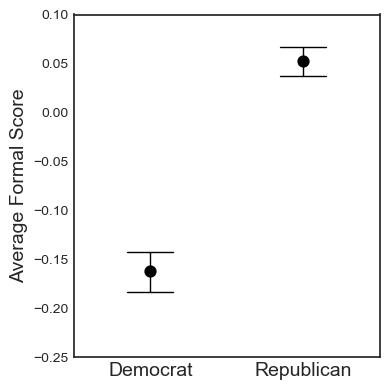

In [ ]:
rep_df = df.dropna(subset=['repub'])

plt.figure(figsize=(4, 4))
sns.pointplot(
    data=rep_df, x="repub", y="zformal",
    errorbar=("ci", 95), join=False, capsize=0.3,
    color="black", errwidth=1, markers="o", 
    dodge=True  # Keeps spacing clear
)
plt.xticks(ticks=[0, 1], labels=["Democrat", "Republican"], fontsize=14)
plt.ylim(-.25, .1)
plt.ylabel("Average Formal Score", fontsize=14)
plt.xlabel("")
plt.tight_layout()
plt.savefig('tiff-figures/president_ideology.tiff', format='tiff', dpi=300)
plt.savefig('figures/president_ideology.png', format='png', dpi=300)

plt.show()


In [17]:
annotation_predictions = pd.read_csv(os.path.join(data_dir, 'annotation_predictions.csv'))
annotation_predictions = annotation_predictions.rename(columns = {'prob_GRAND':'raw_GRAND', 'prob_FORMAL':'raw_FORMAL', 'prob_NONE':'raw_NONE'})
annotation_predictions = annotation_predictions.drop_duplicates(subset = 'section_id')

In [18]:
Counter(annotation_predictions['low_confidence'])

Counter({False: 2599, True: 96})

In [19]:
def permutation_test(df, test_val):
    mean_true = df[df['low_confidence'] == True][test_val].mean()
    mean_false = df[df['low_confidence'] == False][test_val].mean()
    observed_diff = mean_true - mean_false
    print(f"Mean of LC for {test_val}: {mean_true}")
    print(f"Mean of NON-LC for {test_val}: {mean_false}")
    print(f"Observed difference for {test_val}: {observed_diff}")

    combined = df[test_val].values
    low_confidence = df['low_confidence'].values

    n_permutations = 10000
    permutation_diffs = []
    for _ in range(n_permutations):
        shuffled_indices = np.random.permutation(len(low_confidence))
        shuffled_low_confidence = low_confidence[shuffled_indices]

        perm_mean_true = combined[shuffled_low_confidence == True].mean()
        perm_mean_false = combined[shuffled_low_confidence == False].mean()
        permutation_diffs.append(perm_mean_true - perm_mean_false)

    permutation_diffs = np.array(permutation_diffs)
    p_value = (np.sum(np.abs(permutation_diffs) >= np.abs(observed_diff)) + 1) / (n_permutations + 1)
    print(f"Pvalue for {test_val}: {p_value}")
    
    return observed_diff, permutation_diffs
    
def softmax(row):
    exp_vals = np.exp(row - np.max(row))
    return exp_vals / np.sum(exp_vals)

def log_odds(prob):
    return np.log(prob / (1 - prob))

Mean of LC for prob_entropy: 0.7886080248630449
Mean of NON-LC for prob_entropy: 0.5391040509572654
Observed difference for prob_entropy: 0.2495039739057795
Pvalue for prob_entropy: 9.999000099990002e-05


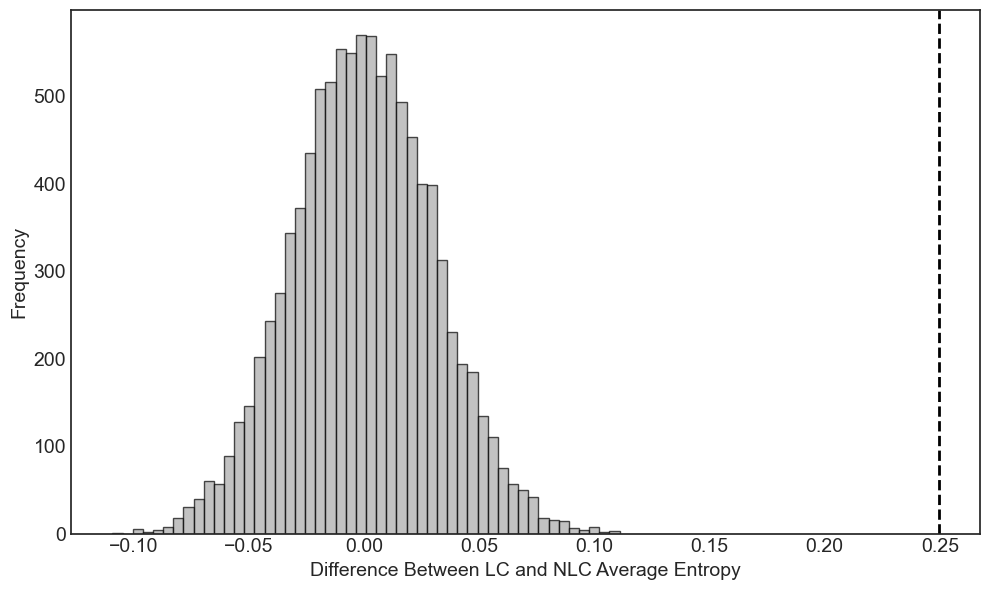

In [ ]:
# Apply softmax to raw model outputs
softmax_values = annotation_predictions[['raw_FORMAL', 'raw_GRAND', 'raw_NONE']].apply(lambda row: softmax(row.values), axis=1)

# Extract softmax values back into separate columns
annotation_predictions['prob_FORMAL'] = softmax_values.apply(lambda x: x[0])
annotation_predictions['prob_GRAND'] = softmax_values.apply(lambda x: x[1])
annotation_predictions['prob_NONE'] = softmax_values.apply(lambda x: x[2])

# Compute entropy for each row
annotation_predictions['prob_entropy'] = softmax_values.apply(lambda x: entropy(x))

# Run permutation test using entropy
observed_diff, permuted_diffs = permutation_test(annotation_predictions, 'prob_entropy')

# Plot the results
plt.figure(figsize=(10, 6))
plt.hist(permuted_diffs, bins=50, color='darkgrey', edgecolor='black', alpha=0.7)
plt.axvline(observed_diff, color='black', linestyle='dashed', linewidth=2)

plt.xlabel('Difference Between LC and NLC Average Entropy', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig(os.path.join('tiff-figures', 'permutation_ave_entropy.tiff'), format='tiff', dpi=300)
plt.savefig(os.path.join('figures', 'permutation_ave_entropy.png'), format='png', dpi=300)

plt.show()